## Baseline Model: TF-IDF + Logistic Regression

This notebook trains a baseline sentiment classification model using
traditional Natural Language Processing techniques.

Steps performed:

1. Load processed training and testing datasets
2. Convert text into TF-IDF features
3. Train a Logistic Regression classifier
4. Evaluate model performance using classification metrics
5. Visualize results using a confusion matrix

The baseline model serves as a reference point for comparison
with the transformer-based model implemented later.

In [2]:
#Imports
#Data Loading

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#Load training and testing datasets created in the data preparation step
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

train_df.head()

,Score,Text,sentiment,label
0,1,Eukanuba is a well-respected name in pet foods...,negative,0
1,1,We tried this with our 10-month-old son and he...,negative,0
2,3,I thought I was getting the standard package t...,neutral,1
3,3,"This food may be good for my cats, but two of ...",neutral,1
4,5,This is my favorite coffee outside of Italy. I...,positive,2


In [3]:
#Feature Preparation

#Seperate features and labels
X_train = train_df["Text"]
y_train = train_df["label"]

X_test = test_df["Text"]
y_test = test_df["label"]

#Convert text reviews into numerical features using TF-IDF
#TF-IDF measures how important a word is within a document relative to the entire dataset.
tfidf = TfidfVectorizer(
    max_features=50000, #Limit vocab size
    ngram_range=(1,2), #Include unigrams and bigrams
    stop_words="english" #Remove english stopwords
)
#Learn vocab from training data
X_train_tfidf = tfidf.fit_transform(X_train)
#Test vocab on learnt vocab
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (102336, 50000)


In [4]:
#Train baseline model - Logistic Regression

clf = LogisticRegression(max_iter=300) #max_iter is increased to ensure model convergence
clf.fit(X_train_tfidf, y_train)

#Predict sentiment labels for the test dataset
y_pred = clf.predict(X_test_tfidf)

              precision    recall  f1-score   support

           0       0.77      0.78      0.78      8528
           1       0.70      0.69      0.69      8528
           2       0.81      0.81      0.81      8528

    accuracy                           0.76     25584
   macro avg       0.76      0.76      0.76     25584
weighted avg       0.76      0.76      0.76     25584



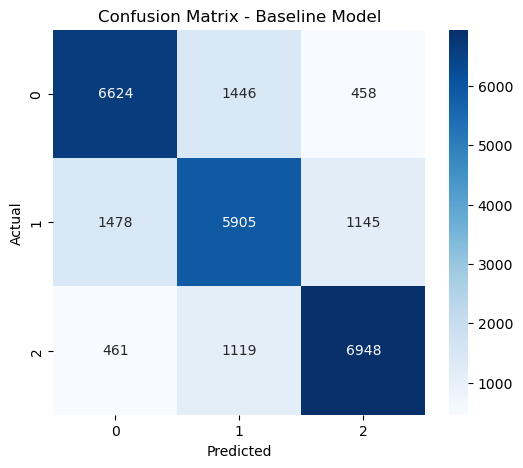

In [5]:
#Evaluation

#Print evaluation metrics
print(classification_report(y_test, y_pred))

#Visualize model performance using a confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Confusion Martix")
plt.show()